In [1]:
!mkdir -p ~/.kaggle

In [2]:
!cp kaggle.json ~/.kaggle

In [3]:
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 90% 310M/346M [00:00<00:00, 872MB/s] 
100% 346M/346M [00:00<00:00, 755MB/s]


In [5]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [27]:
import os
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
train_folder="/content/seg_train/seg_train"
test_folder="/content/seg_test/seg_test"

In [8]:
for sub_folder in os.listdir(train_folder):
  sub_folder_path=os.path.join(train_folder,sub_folder)
  for files in os.listdir(sub_folder_path):
    files_path=os.path.join(sub_folder_path,files)
    img=cv2.imread(files_path)

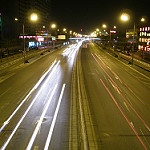

(150, 150, 3)

In [9]:
cv2_imshow(img)
img.shape

In [10]:
train_gen=ImageDataGenerator(
    rescale=1./255,
    # rotation_range=20,
    # horizontal_flip=True,
    # zoom_range=0.2,
    # width_shift_range=0.2,
    # height_shift_range=0.2
)

In [11]:
test_data_gen=ImageDataGenerator(
    rescale=1./255,
)

In [12]:
data_gen= train_gen.flow_from_directory(
    train_folder,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 14034 images belonging to 6 classes.


In [38]:
test_gen= test_data_gen.flow_from_directory(
    test_folder,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [14]:
res_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
res_model.trainable=True

In [16]:
set_trainable=False

for layer in res_model.layers:
  if layer.name=="conv5_block3_1_conv":
    set_trainable=True
  if set_trainable:
    layer.trainable=True
  else:
    layer.trainable=False

In [17]:
for layer in res_model.layers:
  print(layer.name,layer.trainable)

input_layer False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_2_bn False
conv2_block1_2_relu False
conv2_block1_0_conv False
conv2_block1_3_conv False
conv2_block1_0_bn False
conv2_block1_3_bn False
conv2_block1_add False
conv2_block1_out False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_2_bn False
conv2_block2_2_relu False
conv2_block2_3_conv False
conv2_block2_3_bn False
conv2_block2_add False
conv2_block2_out False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_2_bn False
conv2_block3_2_relu False
conv2_block3_3_conv False
conv2_block3_3_bn False
conv2_block3_add False
conv2_block3_out False
conv3_block1_1_conv False
conv3_block1_1_bn False
conv3_block1_1_relu False
conv3_block1_2

In [18]:
res_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 4,465,664 (17.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [19]:
model1=Sequential()
model1.add(res_model)
model1.add(GlobalAveragePooling2D())

model1.add(Dense(128,activation="relu"))
model1.add(Dropout(0.2))
# model2.add(Dense(64,activation="relu"))
# model2.add(Dropout(0.1))
model1.add(Dense(6,activation="softmax"))

In [20]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 4,728,710 (18.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [21]:
callbacks=EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [22]:
model1.compile(optimizer=Adam(learning_rate=0.00001),metrics=["accuracy"],loss="categorical_crossentropy")

In [23]:
history1=model1.fit(data_gen,epochs=25,validation_data=test_gen,callbacks=[callbacks])

Epoch 1/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.5328 - loss: 1.1885 - val_accuracy: 0.5917 - val_loss: 1.0344
Epoch 2/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.6556 - loss: 0.8884 - val_accuracy: 0.6710 - val_loss: 0.8337
Epoch 3/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 123ms/step - accuracy: 0.6943 - loss: 0.8001 - val_accuracy: 0.6853 - val_loss: 0.7866
Epoch 4/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 125ms/step - accuracy: 0.7128 - loss: 0.7472 - val_accuracy: 0.7050 - val_loss: 0.7541
Epoch 5/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 124ms/step - accuracy: 0.7378 - loss: 0.6984 - val_accuracy: 0.7240 - val_loss: 0.7169
Epoch 6/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 125ms/step - accuracy: 0.7491 - loss: 0.6671 - val_accuracy: 0.7303 - val_loss: 0.6933
Epoch 7/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 124ms/step - accuracy: 0.7633 - loss: 0.6342 - val_accuracy: 0.7220 - val_loss: 0.7051
Epoch 8/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 128ms/step - accuracy: 0.7753 - loss: 0

Text(0.5, 1.0, 'Model Accuracy')

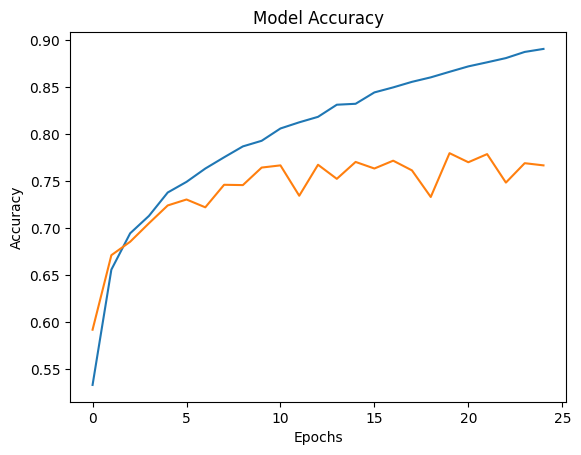

In [24]:
plt.plot(history1.history["accuracy"])
plt.plot(history1.history["val_accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")


Text(0.5, 1.0, 'Model Loss')

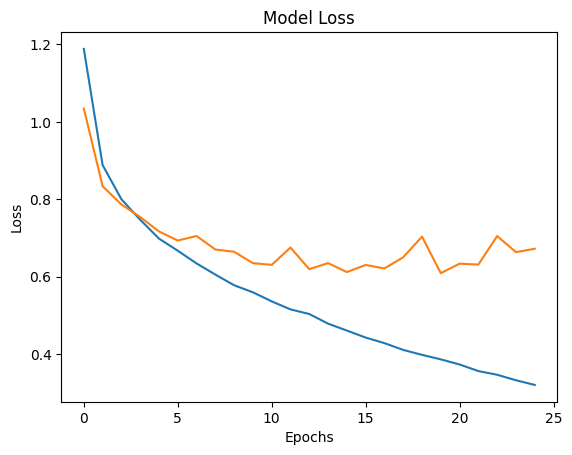

In [25]:
plt.plot(history1.history["loss"])
plt.plot(history1.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")


In [39]:
y_pred=model1.predict(test_gen)

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


In [40]:
y_pred_classes=y_pred.argmax(axis=1)

In [42]:
y_true = test_gen.classes

In [44]:
print(f" Confusion Matrix is: {confusion_matrix(y_true,y_pred_classes)}")

 Confusion Matrix is: [[328   8   6   9  11  75]
 [  3 455   2   5   0   9]
 [  6  10 371 112  45   9]
 [  6   6  67 406  34   6]
 [ 16   8  41  90 346   9]
 [ 35  19   4   4   6 433]]


In [45]:
print(f" Accuracy Score is: {accuracy_score(y_true,y_pred_classes)}")

 Accuracy Score is: 0.7796666666666666


In [46]:
print(f"Classification report is:{classification_report(y_true,y_pred_classes)}")

Classification report is:              precision    recall  f1-score   support

           0       0.83      0.75      0.79       437
           1       0.90      0.96      0.93       474
           2       0.76      0.67      0.71       553
           3       0.65      0.77      0.71       525
           4       0.78      0.68      0.73       510
           5       0.80      0.86      0.83       501

    accuracy                           0.78      3000
   macro avg       0.79      0.78      0.78      3000
weighted avg       0.78      0.78      0.78      3000



In [63]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [64]:
model1.save('/content/drive/MyDrive/Intel_Model.keras')